No podemos llamar a esto un modelo per se en realidad es solo un valod de un peso que vamos a entrenar y veremos como implementar el optimizador Adam comparando con el gradiente descendente estocastico SGD y la acumulacion de gradiente (Gradient acumulation) y que pasa cuando no se reducen los gradientes a cero durante el descenso

In [13]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

# Gráficos vectoriales
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats()

In [14]:
# Inicializar el valor del peso
w = torch.tensor([0.], requires_grad=True) # requires_grad: PyTorch creará un grafo computacional para asociarlo con la variable

# Valor objetivo - valor de pi
target = torch.tensor([torch.pi])

# Tasa de aprendizaje
lr = .01

In [15]:
#create the optimizers - gradiente estocastico y se le pasa el parametro y el Learnig rate
optimizer = torch.optim.SGD([w],lr=lr)

# number of training iterations epochs
numIters = 150

# initialize results matrices / solo para que podamos ver el rendimiento despues del entranamiento
all_losses  = np.zeros(numIters)
all_weights = np.zeros(numIters+1)
all_weights[0] = w.item() # initial value / primer parametro que en este caso es 0

In [18]:
%matplotlib inline
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

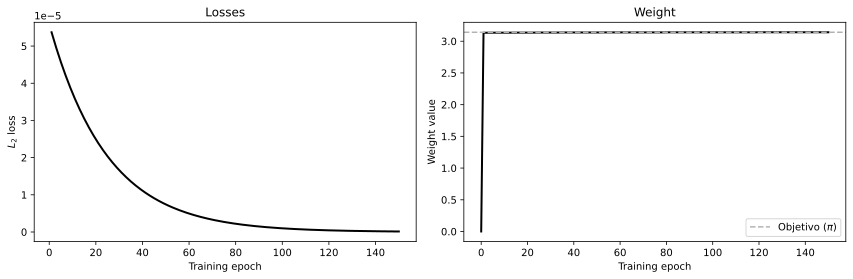

In [19]:
### Bucle de entrenamiento
for i in range(numIters):

  # Entrenar el peso
  optimizer.zero_grad() #
  loss = (w - target)**2 # El cuadrado aporta convexidad y una derivada analítica sencilla
  loss.backward() # Aquí se calculan todos los gradientes
  optimizer.step() # Aquí se actualizan los pesos con el optimizador

  # Almacenar la pérdida y el valor del peso
  all_losses[i] = loss.item() # Almacenando la pérdida
  all_weights[i+1] = w.item() # Almacenando el peso

  # Veremos que cuando entrenemos LLMs es casi lo mismo, pero esto es esencialmente lo que necesitamos


#### Visualización
_, axs = plt.subplots(1, 2, figsize=(12, 4))

# Graficar las pérdidas y los valores del peso
axs[0].plot(range(1, numIters + 1), all_losses, 'k', linewidth=2)
axs[1].plot(range(0, numIters + 1), all_weights, 'k', linewidth=2)

axs[0].set(title='Losses', ylabel=r'$L_2$ loss', xlabel='Training epoch')
axs[1].set(title='Weight', ylabel='Weight value', xlabel='Training epoch')
axs[1].axhline(target.item(), linestyle='--', color=[.7, .7, .7], label=r'Objetivo ($\pi$)')
axs[1].legend()

plt.tight_layout()
plt.show()

## Con variables separadas

In [127]:
# AHORA CON VARIAS FUNCIONES Y TRES VARIABLES SEPARADAS

In [128]:
# initialize weight value / pesos inicializados y activado los gradientes
wSGD   = torch.tensor([2.], requires_grad=True)
wAdam  = torch.tensor([2.], requires_grad=True)
wAdamW = torch.tensor([2.], requires_grad=True)

# target value / el target es el mismo para todos
target = torch.tensor([5.])

In [129]:
# learning rates (equal for exercises 1&3; changed in exercise 2) # Tasas de aprendizaje
learningrateSGD = 0.05
learningrateAdm = 0.05

# Valores utilizados:
#learningrateSGD = .04
#learningrateAdm = .1


In [130]:
# Crear los optimizadores
optimizerSGD   = torch.optim.SGD([wSGD],     lr=learningrateSGD)
optimizerAdam  = torch.optim.Adam([wAdam],   lr=learningrateAdm)
optimizerAdamW = torch.optim.AdamW([wAdamW], lr=learningrateAdm)

In [131]:
# number of training iterations
numIters = 50

In [132]:
# Inicializar matrices de resultados
all_losses  = np.zeros((3, numIters))
all_weights = np.zeros((3, numIters + 1))
all_weights[:, 0] = [wSGD.item(), wAdam.item(), wAdamW.item()]

In [142]:
for i in range(numIters):

  # Entrenar el peso con SGD
  optimizerSGD.zero_grad()
  lossSGD = (wSGD - target)**2
  lossSGD.backward()
  optimizerSGD.step()

  # Entrenar con Adam
  optimizerAdam.zero_grad()
  lossAdam = (wAdam - target)**2
  lossAdam.backward()
  optimizerAdam.step()

  # Entrenar con AdamW
  optimizerAdamW.zero_grad()
  lossAdamW = (wAdamW - target)**2
  lossAdamW.backward()
  optimizerAdamW.step()

  # Almacenar las pérdidas y los valores actualizados de los pesos
  all_losses[0, i] = lossSGD.item()
  all_losses[1, i] = lossAdam.item()
  all_losses[2, i] = lossAdamW.item()

  all_weights[0, i+1] = wSGD.item()
  all_weights[1, i+1] = wAdam.item()
  all_weights[2, i+1] = wAdamW.item()

  print(f'{wAdam.grad.item():7.3f} {wAdamW.grad.item():7.3f}') # VALORES REALAES DEL GRADIENTE derivados  ej4

  0.010  -0.111
  0.010  -0.110
  0.009  -0.110
  0.009  -0.110
  0.009  -0.110
  0.008  -0.110
  0.008  -0.109
  0.008  -0.109
  0.007  -0.109
  0.007  -0.109
  0.006  -0.109
  0.006  -0.109
  0.006  -0.109
  0.005  -0.108
  0.005  -0.108
  0.005  -0.108
  0.004  -0.108
  0.004  -0.108
  0.004  -0.108
  0.003  -0.108
  0.003  -0.107
  0.003  -0.107
  0.003  -0.107
  0.002  -0.107
  0.002  -0.107
  0.002  -0.107
  0.002  -0.106
  0.002  -0.106
  0.001  -0.106
  0.001  -0.106
  0.001  -0.106
  0.001  -0.105
  0.001  -0.105
  0.001  -0.105
  0.000  -0.105
  0.000  -0.104
  0.000  -0.104
  0.000  -0.104
  0.000  -0.104
  0.000  -0.103
 -0.000  -0.103
 -0.000  -0.103
 -0.000  -0.103
 -0.000  -0.102
 -0.000  -0.102
 -0.000  -0.102
 -0.000  -0.101
 -0.000  -0.101
 -0.000  -0.101
 -0.000  -0.101


In [134]:
# Esta celda estaba causando un 'IndentationError' porque su contenido estaba indentado innecesariamente.
# Además, el código para almacenar las pérdidas y los pesos ya fue integrado en el bucle de entrenamiento (celda YpHkrVuuB5TJ).
# Por lo tanto, se ha vaciado el contenido de esta celda.

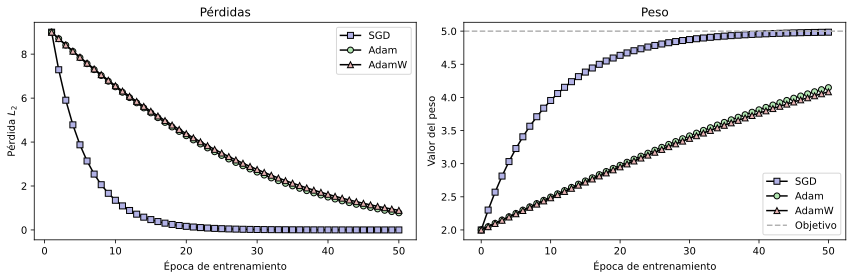

In [135]:
_, axs = plt.subplots(1, 2, figsize=(12, 4))

# Etiquetas y marcadores
optimlabels = ['SGD', 'Adam', 'AdamW']
markercols = [[.7, .7, .9], [.7, .9, .7], [.9, .7, .7]]
shapes = 'so^'

# Recorrer los optimizadores y graficar
for i in range(3):

  # Graficar las pérdidas
  axs[0].plot(range(1, numIters + 1), all_losses[i, :], 'k', marker=shapes[i],
              markerfacecolor=markercols[i], label=optimlabels[i])

  # Graficar los pesos
  axs[1].plot(range(0, numIters + 1), all_weights[i, :], 'k', marker=shapes[i],
              markerfacecolor=markercols[i], label=optimlabels[i])

axs[0].set(title='Pérdidas', ylabel=r'Pérdida $L_2$', xlabel='Época de entrenamiento')
axs[1].set(title='Peso', ylabel='Valor del peso', xlabel='Época de entrenamiento')
axs[1].axhline(target.item(), linestyle='--', color=[.7, .7, .7], label='Objetivo')

for a in axs:
  a.legend()

plt.tight_layout()
plt.show()

In [136]:
# pensaremos que solo hay dos lineas / el estocastico lo hizo mejor que el adam (La ventaja de adam es en grandes Modelos)

* **Sin regularización ($\text{Weight Decay} = 0$):** **Adam y AdamW son exactamente el mismo algoritmo**. No existe diferencia matemática ni práctica en sus cálculos.
* **Con regularización:** La discrepancia en la fórmula parece mínima (desacoplar la contracción del cálculo del segundo momento adaptativo).
* **El efecto de la escala:** En redes neuronales pequeñas con pocos parámetros, este detalle es prácticamente imperceptible; sin embargo, **en modelos con cientos de miles de millones de parámetros**, ese pequeño sesgo acumulado a lo largo de billones de pasos de gradiente distorsiona la escala de los pesos, marcando la diferencia entre el colapso del entrenamiento y una convergencia estable.

# Con diferentes valores del Lr

In [137]:
# Valores utilizados:
learningrateSGD = .04
learningrateAdm = .1

In [87]:
# cambiar a 150 iteraciones

Adam ralentiza y suaviza el aprendizaje, lo cual resulta muy ventajoso: si tenemos un modelo muy simple con un objetivo sumamente claro, en realidad no queremos frenar el proceso, sino aprender lo más rápido posible.

Sin embargo, cuando trabajamos con un modelo complejo y de alta dimensionalidad (como un LLM), no queremos que los pesos reboten de forma caótica dentro de ese espacio. En esos escenarios interesa ralentizar y estabilizar el ritmo de actualización, logrando una trayectoria de optimización suave y controlada hacia el conjunto óptimo de pesos.

## Cuando no se restablecen los gradientes

## Mecánica del Gradiente y Estrategias de Lote

### 1. Principio Fundamental del Descenso de Gradiente
La idea central de la optimización basada en gradiente consiste en:
1. Calcular la **derivada (gradiente)** de la función de pérdida respecto a los parámetros: $\nabla_\theta \mathcal{L}$.
2. Ajustar los pesos en la **dirección opuesta** al gradiente (hacia el mínimo).
3. Escalar la magnitud del paso mediante una tasa de aprendizaje ($\eta$), de modo que el avance sea proporcional a la pendiente del error:

$$\theta_{t+1} = \theta_t - \eta \nabla_\theta \mathcal{L}$$

---

### 2. SGD vs. Mini-batch Learning

* **Stochastic Gradient Descent (SGD puro):**
  * Ajusta las ponderaciones inmediatamente después de procesar **cada muestra individual** de datos ($N = 1$).
  * Funciona en problemas simples, pero introduce una varianza excesiva y no aprovecha el paralelismo matricial del hardware.

* **Mini-batch Gradient Descent:**
  * A medida que los datos y los modelos se vuelven más complejos, se procesa un lote de muestras (por ejemplo, **32, 64 o 128 datos**) antes de actualizar los pesos.
  * Se calcula la pérdida para cada elemento y se obtiene el **gradiente promedio** del lote:
  
  $$g_t = \frac{1}{B} \sum_{i=1}^B \nabla_\theta \mathcal{L}(x_i, y_i; \theta_t)$$

---

### 3. Acumulación de Gradientes (*Gradient Accumulation*)

El procesamiento por lotes puede entenderse conceptualmente como una suma acumulada de gradientes individuales que luego se promedia.

Esta idea da lugar a la técnica de **Acumulación de Gradientes**, indispensable al entrenar modelos masivos (como LLMs):
* **El problema de memoria (VRAM):** Cuando un modelo gigante y un lote de datos grande no caben simultáneamente en la memoria de la GPU, no es posible usar un tamaño de lote elevado directamente.
* **La solución:**
  1. Se procesan micro-lotes pequeños que sí quepan en la GPU.
  2. Se acumulan (suman) los gradientes calculados a lo largo de varios pasos hacia adelante (*forward*) y hacia atrás (*backward*) sin actualizar los pesos de inmediato.
  3. Tras $k$ micro-pasos, se divide el gradiente acumulado entre $k$ y el optimizador ejecuta **un único paso de actualización**.
* **Resultado:** Permite simular de forma exacta un tamaño de lote global masivo (ej. 512 o 1024) utilizando únicamente la memoria requerida por un micro-lote pequeño.

In [138]:
# es un poco un truco informatico

In [146]:
# Inicializar pesos y target
wSGD   = torch.tensor([2.], requires_grad=True)
wAdam  = torch.tensor([2.], requires_grad=True)
wAdamW = torch.tensor([2.], requires_grad=True)
target = torch.tensor([5.])

# SGD en 1.0 para provocar el ciclo oscilatorio puro
learningrateSGD = 1.0
learningrateAdm = 0.05

optimizerSGD   = torch.optim.SGD([wSGD],     lr=learningrateSGD)
optimizerAdam  = torch.optim.Adam([wAdam],   lr=learningrateAdm)
optimizerAdamW = torch.optim.AdamW([wAdamW], lr=learningrateAdm)

In [147]:
numIters = 50

# Inicializar matrices de resultados
all_losses  = np.zeros((3, numIters))
all_weights = np.zeros((3, numIters + 1))
all_weights[:, 0] = [wSGD.item(), wAdam.item(), wAdamW.item()]

for i in range(numIters):

  # SGD
  optimizerSGD.zero_grad()
  lossSGD = (wSGD - target)**2
  lossSGD.backward()
  optimizerSGD.step()

  # Adam
  optimizerAdam.zero_grad()
  lossAdam = (wAdam - target)**2
  lossAdam.backward()
  optimizerAdam.step()

  # AdamW
  optimizerAdamW.zero_grad()
  lossAdamW = (wAdamW - target)**2
  lossAdamW.backward()
  optimizerAdamW.step()

  # Almacenar métricas
  all_losses[0, i] = lossSGD.item()
  all_losses[1, i] = lossAdam.item()
  all_losses[2, i] = lossAdamW.item()

  all_weights[0, i+1] = wSGD.item()
  all_weights[1, i+1] = wAdam.item()
  all_weights[2, i+1] = wAdamW.item()

# Comparación de gradientes finales
print(f'Gradiente Adam: {wAdam.grad.item():7.3f} | Gradiente AdamW: {wAdamW.grad.item():7.3f}')

Gradiente Adam:  -1.765 | Gradiente AdamW:  -1.889


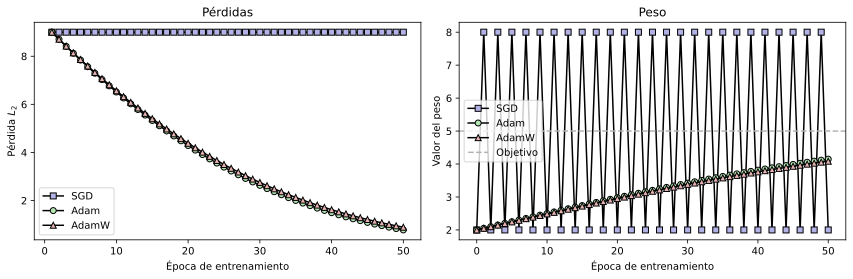

In [148]:
_, axs = plt.subplots(1, 2, figsize=(12, 4))

optimlabels = ['SGD', 'Adam', 'AdamW']
markercols = [[.7, .7, .9], [.7, .9, .7], [.9, .7, .7]]
shapes = 'so^'

for i in range(3):
  axs[0].plot(range(1, numIters + 1), all_losses[i, :], 'k', marker=shapes[i],
              markerfacecolor=markercols[i], label=optimlabels[i])
  axs[1].plot(range(0, numIters + 1), all_weights[i, :], 'k', marker=shapes[i],
              markerfacecolor=markercols[i], label=optimlabels[i])

axs[0].set(title='Pérdidas', ylabel=r'Pérdida $L_2$', xlabel='Época de entrenamiento')
axs[1].set(title='Peso', ylabel='Valor del peso', xlabel='Época de entrenamiento')
axs[1].axhline(target.item(), linestyle='--', color=[.7, .7, .7], label='Objetivo')

for a in axs:
  a.legend()

plt.tight_layout()
plt.show()

### Aclaración técnica: Gradientes en Cero vs. Pesos Inicializados

Es fundamental no confundir la **inicialización de los pesos** con el **reinicio de los gradientes**:

* **Los pesos ($W$) NUNCA se inicializan en cero:**  
  Si inicializamos todos los pesos de una red neuronal en cero, todas las neuronas de una misma capa calcularán exactamente la misma salida y recibirán exactamente el mismo gradiente. Esto provoca el problema de **simetría**, impidiendo que la red aprenda características distintas. Los pesos siempre se inicializan con métodos aleatorios estructurados como **He / Kaiming** o **Xavier / Glorot**.

* **Lo que se reinicia a cero son los GRADIENTES ($\nabla W$):**  
  En frameworks como PyTorch, la operación `loss.backward()` está diseñada para **acumular (sumar)** los gradientes por defecto en lugar de sobreescribirlos.

---

### El porqué del reseteo manual de gradientes

Debido a este comportamiento de acumulación por defecto:

1. **En entrenamiento estándar:**  
   Debemos limpiar manualmente los gradientes acumulados en cada iteración antes de calcular los del nuevo lote, utilizando:
   ```python
   optimizer.zero_grad(set_to_none=True)  # Limpia los gradientes del paso anterior
   loss.backward()                        # Calcula los nuevos gradientes
   optimizer.step()                       # Aplica la actualización de pesos